In [1]:
import torch

load config

In [2]:
from loopr.config.training_nn import TrainingNNConfig

Visualize Data

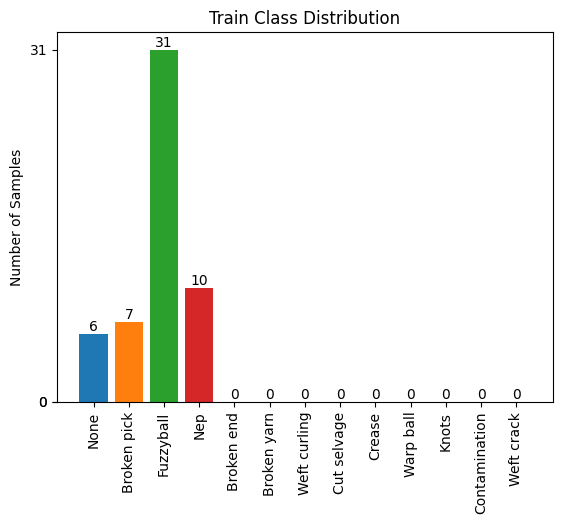

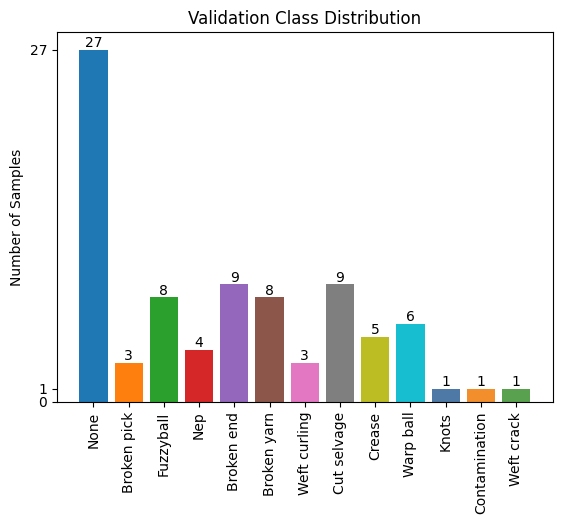

In [3]:
from loopr.eda.class_visualization import number_of_files_per_class
from loopr.data.classification import (
    ClassificationDataset)
from loopr.data.contrastive import get_train_transforms, get_valid_transforms
train_ds =  ClassificationDataset(
    transforms=get_train_transforms(), 
    training=True,
    train_split=TrainingNNConfig.train_split,
    censor_files=False,
    crop=True,
    limited_classes={0:5}
)
val_ds =  ClassificationDataset(
    transforms=get_valid_transforms(), 
    training=False,
    train_split=TrainingNNConfig.train_split,
    censor_files=False,
    crop=True,
    
)

number_of_files_per_class(train_ds, val_ds)

In [ ]:

from loopr.training.train_neural_net import train_neural_net
train_neural_net()

epoch: 0
Train Loss (BCE + lambda * L2): 1.4158137014933996
Validation Loss (BCE + lambda * L2): 1.2725880425423384
Validation Score (F1 micro score): 0.666403162055336
epoch: 1
Train Loss (BCE + lambda * L2): 0.7165650171892983
Validation Loss (BCE + lambda * L2): 0.7632866948843002
Validation Score (F1 micro score): 0.07142857142857142
epoch: 2
Train Loss (BCE + lambda * L2): 0.47595250819410595
Validation Loss (BCE + lambda * L2): 0.5473020076751709
Validation Score (F1 micro score): 0.5516304347826086
epoch: 3
Train Loss (BCE + lambda * L2): 0.42072646958487375
Validation Loss (BCE + lambda * L2): 0.43874530494213104
Validation Score (F1 micro score): 0.6375
epoch: 4
Train Loss (BCE + lambda * L2): 0.4828044016446386
Validation Loss (BCE + lambda * L2): 0.5793536081910133
Validation Score (F1 micro score): 0.0
epoch: 5
Train Loss (BCE + lambda * L2): 0.48181233022894177
Validation Loss (BCE + lambda * L2): 0.5576045513153076
Validation Score (F1 micro score): 0.6239130434782609
epo

In [ ]:
from loopr.models.mlp import create_mlp
from loopr.models.unet import load_unet
centroids = []
mlp = create_mlp()
unet_model = load_unet()
linear_layer = list(mlp.children())[0].cuda()
train_ds.crop = False

In [ ]:
from loopr.data.utils import tile_image
import torch
total_embeddings = torch.zeros(1+len(train_ds.all_classes), 16*7)
counts = [0 for i in range(1+len(train_ds.all_classes))]
for i, (image, individual_class, meta) in enumerate(train_ds):

    image_tiles = tile_image(image)
    embeddings = unet_model.encode(image_tiles.cuda())
    embeddings = embeddings.reshape(len(image_tiles),-1)
    domain_embedded = linear_layer(embeddings).reshape(-1)
    total_embeddings[individual_class,:] += domain_embedded.cpu().detach()
    counts[individual_class] += 1
for i in range(1+len(train_ds.all_classes)):
    total_embeddings[individual_class,:] /= counts[individual_class]
    

In [ ]:
torch.save(total_embeddings, TrainingNNConfig.centroid_file)

In [ ]:
total_embeddings.shape